In [1]:
from bs4 import BeautifulSoup
import json, os, re, requests, sys, time
import pandas as pd


In [2]:
page = 196

In [3]:
r = requests.get(f'https://www.superherodb.com/characters/?page_nr={page}')
c = BeautifulSoup(r.content, 'html.parser')

In [42]:
for contents in c.body.main.div.contents[7:-2]:
    try:
        for a in contents('a'):
            print(a.contents[0], a['href'])  
    except:
        pass

Yuzu /yuzu/10-61855/
Yuzuriha /yuzuriha/10-56702/
Yve /yve/10-53403/
Yveltal /yveltal/10-24201/
Yveltal (Cocoon Form) /yveltal-cocoon-form/10-62336/
Yvette /yvette/10-36026/
Yvette Steckley-Douglas /yvette-steckley-douglas/10-26875/
Yvraine /yvraine/10-56144/
Yylfordt Granz /yylfordt-granz/10-50003/
Yzma /yzma/10-19644/
Z /z/10-10368/
Z /z/10-49034/
Z'Cann (Skrull) /zcann-skrull/10-56433/
Z'neth /zneth/10-56607/
Z-ARC /z-arc/10-48583/
Z-one /z-one/10-48647/
Z.C. Branke /zc-branke/10-56127/
Za Priccio /za-priccio/10-28638/
Za-Naron /za-naron/10-47321/
Zab /zab/10-1090/
Zabro Gaze /zabro-gaze/10-55072/
Zabu /zabu/10-43336/
Zabu /zabu/10-63204/
Zabuza /zabuza/10-15590/
Zac /zac/10-47184/
Zac Blakely /zac-blakely/10-66929/
Zac Kaneguro /zac-kaneguro/10-24833/
Zacama /zacama/10-34716/
Zacaré /zacar/10-53282/
Zach /zach/10-54633/
Zach /zach/10-44423/
Zach Hamilton /zach-hamilton/10-66263/
Zachariah /zachariah/10-42403/
Zacharias Smith /zacharias-smith/10-29097/
Zachary Kralik /zachary-kralik

In [31]:
for a in c.body.main.div.contents[7]('a'):
    print(a.contents[0], a['href'])

Yuzu /yuzu/10-61855/
Yuzuriha /yuzuriha/10-56702/
Yve /yve/10-53403/
Yveltal /yveltal/10-24201/
Yveltal (Cocoon Form) /yveltal-cocoon-form/10-62336/
Yvette /yvette/10-36026/
Yvette Steckley-Douglas /yvette-steckley-douglas/10-26875/
Yvraine /yvraine/10-56144/
Yylfordt Granz /yylfordt-granz/10-50003/
Yzma /yzma/10-19644/


In [42]:
h = {'name': 'Batman', 'href': '/tartaglia/10-15560/'}

In [43]:
r = requests.get('https://www.superherodb.com' + h['href'], timeout=200)
c = BeautifulSoup(r.content, 'html.parser')

In [44]:
c.title

<title>Batman - DC One Million - Superhero Database</title>

In [45]:
c.h1.string

'Batman'


<!DOCTYPE html>

<html lang="en-US">
<head>
<script>
    
    var showads = true;var testsever = false;        
    </script>
<script>(function(w,d,s,l,i){w[l]=w[l]||[];w[l].push({'gtm.start':
    new Date().getTime(),event:'gtm.js'});var f=d.getElementsByTagName(s)[0],
    j=d.createElement(s),dl=l!='dataLayer'?'&l='+l:'';j.async=true;j.src=
    'https://www.googletagmanager.com/gtm.js?id='+i+dl;f.parentNode.insertBefore(j,f);
    })(window,document,'script','dataLayer','GTM-W865B8C');</script>
<script async="" src="/js/freestar-quantcast.min.js" type="text/javascript"></script>
<script data-cfasync="false" type="text/javascript">
  (()=>{"use strict";var t={455:(t,e,n)=>{n.d(e,{Z:()=>c});var r=n(81),o=n.n(r),i=n(645),a=n.n(i)()(o());a.push([t.id,'div._82u8vq{position:fixed;top:0;left:0;width:100%;height:100%;background:rgba(0,0,0,.4);z-index:999999}div._82u8vq *{box-sizing:border-box}div._82u8vq div.onnj2g{position:fixed;top:50%;left:50%;transform:translate(-50%, -50%);display:flex;
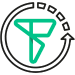
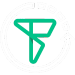

In [46]:
c

In [47]:
h['identity'] = c.h2.string

In [48]:
stats = c.find_all('div', class_='stat-holder')[0].next_sibling.string
start = stats.find('bars')
stats = stats[start+6:]
end = stats.find('}')
stats = stats[:end+1]
stats = json.loads(stats)
h['intelligence'] = stats['int']
h['strength'] = stats['str']
h['speed'] = stats['spe']
h['durability'] = stats['dur']
h['power'] = stats['pow']
h['combat'] = stats['com']


In [49]:
powers_sect = c.find(lambda tag: tag.string=='Super Powers')
if powers_sect:
    powers = powers_sect.parent.contents
    h['powers'] = [t.i.next_sibling for t in powers if t.name=='a']
else:
    h['powers'] = ''


In [50]:
origin_sect = c.find(lambda tag: tag.string=='Origin')
origin = origin_sect.next_sibling.next_sibling('tr')
fields = [list(f.stripped_strings) for f in origin]
fields

[['Creator', 'DC Comics'],
 ['Universe', 'One Million - DC One Million'],
 ['Full name'],
 ['Alter Egos', 'No alter egos found.'],
 ['Aliases'],
 ['Place of birth'],
 ['First appearance'],
 ['Alignment', 'Good']]

In [51]:
field_names = ('Universe', 'Full name',
               'Place of birth', 'Alignment',
               'First appearance', 'Creator')
for f in fields:
    if f[0] in field_names:
        f[0] = f[0].lower()
        if len(f) == 1:
            f.append('')
        h[f[0]] = f[1]

In [52]:
h

{'name': 'Batman',
 'href': '/tartaglia/10-15560/',
 'identity': None,
 'intelligence': 100,
 'strength': 25,
 'speed': 50,
 'durability': 13,
 'power': 30,
 'combat': 100,
 'powers': ['Acrobatics',
  'Enhanced Memory',
  'Intelligence',
  'Marksmanship',
  'Master Martial Artist',
  'Master Tactician',
  'Mechanical Aptitude',
  'Weapon Creation',
  'Weapon-based Powers',
  'Weapons Master',
  'Anti-Gravity',
  'Camouflage',
  'Cloaking',
  'Duplication',
  'Electrokinesis',
  'Element Control',
  'Enhanced Sight',
  'Explosion Manipulation',
  'Fire Resistance',
  'Flight',
  'Gliding',
  'Gravity Control',
  'Heat Resistance',
  'Homing Attack',
  'Illusions',
  'Invisibility',
  'Power Suit',
  'Soul Manipulation',
  'Supernatural Condition',
  'Technopath/Cyberpath',
  'Telepathy',
  'Vehicular Mastery',
  'Vision - Night'],
 'creator': 'DC Comics',
 'universe': 'One Million - DC One Million',
 'full name': '',
 'place of birth': '',
 'first appearance': '',
 'alignment': 'Good'}

In [53]:
appearance_sect = c.find(lambda tag: tag.string=='Appearance')
appearance = appearance_sect.next_sibling.next_sibling('tr')
fields = [list(f.stripped_strings) for f in appearance]
fields


[['Gender', 'Male'],
 ['Species // Type', 'Alien'],
 ['Height', '198.1 cm • 6\'6"'],
 ['Weight', '106.6 kg • 235.01 lbs'],
 ['Eye color', 'Blue'],
 ['Hair color', 'Blond']]

In [54]:
field_names = ('Gender', 'Height', 'Weight', 
               'Eye color', 'Hair color')


for f in fields:
    if f[0] in field_names:
        f[0] = f[0].lower()
        if len(f) == 1:
            f.append('')
        h[f[0]] = f[1]


In [55]:
h

{'name': 'Batman',
 'href': '/tartaglia/10-15560/',
 'identity': None,
 'intelligence': 100,
 'strength': 25,
 'speed': 50,
 'durability': 13,
 'power': 30,
 'combat': 100,
 'powers': ['Acrobatics',
  'Enhanced Memory',
  'Intelligence',
  'Marksmanship',
  'Master Martial Artist',
  'Master Tactician',
  'Mechanical Aptitude',
  'Weapon Creation',
  'Weapon-based Powers',
  'Weapons Master',
  'Anti-Gravity',
  'Camouflage',
  'Cloaking',
  'Duplication',
  'Electrokinesis',
  'Element Control',
  'Enhanced Sight',
  'Explosion Manipulation',
  'Fire Resistance',
  'Flight',
  'Gliding',
  'Gravity Control',
  'Heat Resistance',
  'Homing Attack',
  'Illusions',
  'Invisibility',
  'Power Suit',
  'Soul Manipulation',
  'Supernatural Condition',
  'Technopath/Cyberpath',
  'Telepathy',
  'Vehicular Mastery',
  'Vision - Night'],
 'creator': 'DC Comics',
 'universe': 'One Million - DC One Million',
 'full name': '',
 'place of birth': '',
 'first appearance': '',
 'alignment': 'Good',
